# Anomaly Clustering

Cluster anomalies detected by Transformer+OC-SVM, PNN (spoofing gain), and PRAE (RFDR).

In [2]:
import os
import sys
import glob
import logging
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, os.path.abspath(".."))

from detection.data.loaders import create_sequences
from detection.models import hybrid, pnn as pnn_module, prae as prae_module
from detection.models.transformer import BottleneckTransformer
from detection.spoofing.gain import compute_spoofing_gains_batch
from detection.thresholds.rfdr import RollingFalseDiscoveryRate

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger(__name__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
DATA_DIR = os.path.join("..", "data", "processed", "TOTF.PA-book")
RESULTS_DIR = os.path.join("..", "results")
MODEL_TYPES = ["transformer_ocsvm", "pnn", "prae"]

SEQ_LENGTH = 25
BATCH_SIZE = 64

LOB_COLUMNS = [
    f"{side}-{typ}-{lvl}"
    for lvl in range(1, 11)
    for side, typ in [
        ("bid", "price"),
        ("bid", "volume"),
        ("ask", "price"),
        ("ask", "volume"),
    ]
]

SPOOF_Q = 4500
SPOOF_q = 100
SPOOF_DELTA_A = 0.0
SPOOF_DELTA_B = 0.01
SPOOF_FEES = {"maker": 0.0, "taker": 0.05}

RFDR_WINDOW = 500
RFDR_ALPHA = 0.05

PERIODS = {
    "1st_hour": (9.0, 10.0),
    "rest_of_morning": (10.0, 12.0),
    "afternoon": (12.0, 15.5),
    "american_open": (15.5, 17.5),
}

KMEANS_K_RANGE = range(2, 7)
RANDOM_STATE = 42

FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
TEST_FILES = [FILES[-3]]

In [4]:
def load_processed(filepath):
    full = pd.read_parquet(filepath)
    meta_cols = ["xltime"] + [c for c in LOB_COLUMNS if c in full.columns]
    meta_set = set(meta_cols)
    feat_cols = [c for c in full.columns if c not in meta_set]
    return full[meta_cols], full[feat_cols]


def get_time_frac(df):
    base_date = np.floor(df["xltime"].values)
    return df["xltime"].values - base_date


def assign_period(time_frac_arr):
    labels = np.full(len(time_frac_arr), "unknown", dtype=object)
    for name, (open_h, close_h) in PERIODS.items():
        mask = (time_frac_arr >= open_h / 24.0) & (time_frac_arr < close_h / 24.0)
        labels[mask] = name
    return labels


def build_model(model_type, num_features, weights_path):
    if model_type == "transformer_ocsvm":
        transformer = BottleneckTransformer(
            num_features=num_features,
            model_dim=64,
            num_heads=4,
            num_layers=2,
            representation_dim=128,
            sequence_length=SEQ_LENGTH,
        )
        transformer.load_state_dict(
            torch.load(weights_path, map_location=DEVICE, weights_only=True)
        )
        transformer.eval().to(DEVICE)
        ocsvm_path = weights_path.replace("_weights.pth", "_detector.pth")
        ocsvm = (
            torch.load(ocsvm_path, map_location=DEVICE, weights_only=False)
            if os.path.exists(ocsvm_path)
            else None
        )
        return transformer, ocsvm

    if model_type == "pnn":
        input_dim = SEQ_LENGTH * num_features
        model = pnn_module.PNN(input_dim=input_dim, hidden_dim=64).to(DEVICE)
        model.load_state_dict(
            torch.load(weights_path, map_location=DEVICE, weights_only=True)
        )
        model.eval()
        return model, None

    if model_type == "prae":
        backbone = BottleneckTransformer(
            num_features=num_features,
            model_dim=64,
            num_heads=4,
            num_layers=2,
            representation_dim=128,
            sequence_length=SEQ_LENGTH,
        )
        model = prae_module.PRAE(
            backbone_model=backbone,
            num_train_samples=1,
            lambda_reg=1.0,
            sigma=0.5,
        ).to(DEVICE)
        state_dict = torch.load(weights_path, map_location=DEVICE, weights_only=True)
        state_dict = {k: v for k, v in state_dict.items() if k != "mu"}
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        return model, None

    raise ValueError(f"Unknown model type: {model_type}")

In [5]:
feature_names_map = {}
for mt in MODEL_TYPES:
    feat_path = os.path.join(RESULTS_DIR, f"{mt}_features.txt")
    if os.path.exists(feat_path):
        with open(feat_path) as fh:
            feature_names_map[mt] = [ln.strip() for ln in fh if ln.strip()]
    else:
        _, tmp = load_processed(TEST_FILES[0])
        feature_names_map[mt] = tmp.columns.tolist()

loaded_models = {}
loaded_scalers = {}
for model_type in MODEL_TYPES:
    feat_names = feature_names_map[model_type]
    weights_path = os.path.join(RESULTS_DIR, f"{model_type}_weights.pth")
    model, ocsvm = build_model(model_type, len(feat_names), weights_path)
    loaded_models[model_type] = (model, ocsvm)

    scaler_path = os.path.join(RESULTS_DIR, f"{model_type}_scaler.pkl")
    loaded_scalers[model_type] = (
        joblib.load(scaler_path) if os.path.exists(scaler_path) else MinMaxScaler()
    )

In [6]:
all_scores = {mt: [] for mt in MODEL_TYPES}
all_preds = {mt: [] for mt in MODEL_TYPES}
all_period_labels = []
all_feat_values = []
day_boundaries = [0]

for test_file in TEST_FILES:
    df_day, features_day = load_processed(test_file)
    time_frac_day = get_time_frac(df_day)[: len(features_day)]
    period_labels = assign_period(time_frac_day)
    spread_raw = (df_day["ask-price-1"] - df_day["bid-price-1"]).values
    n_seq = len(features_day) - SEQ_LENGTH

    all_period_labels.append(period_labels[SEQ_LENGTH : SEQ_LENGTH + n_seq])
    all_feat_values.append(
        features_day.iloc[SEQ_LENGTH : SEQ_LENGTH + n_seq].reset_index(drop=True)
    )

    for model_type in MODEL_TYPES:
        logger.info(f"Processing {model_type} for file {os.path.basename(test_file)}")
        feat_names = feature_names_map[model_type]
        scaler = loaded_scalers[model_type]
        model, ocsvm = loaded_models[model_type]

        feat_df = features_day.copy()
        for col in feat_names:
            if col not in feat_df.columns:
                feat_df[col] = 0.0
        feat_df = feat_df[feat_names]

        scaled = scaler.transform(feat_df.values.astype(np.float32)).astype(np.float32)
        sequences = create_sequences(scaled, SEQ_LENGTH)

        if model_type == "transformer_ocsvm":
            x_tensor = torch.tensor(sequences, dtype=torch.float32)
            loader = DataLoader(
                TensorDataset(x_tensor, x_tensor), batch_size=BATCH_SIZE, shuffle=False
            )
            if ocsvm is not None:
                detector = hybrid.TransformerOCSVM.__new__(hybrid.TransformerOCSVM)
                detector.transformer = model
                detector.ocsvm = ocsvm
                scores = detector.predict(loader)
            else:
                scores_list = []
                with torch.no_grad():
                    for batch in loader:
                        x = batch[0].to(DEVICE)
                        rec = model(x)
                        scores_list.append(
                            torch.mean((x - rec) ** 2, dim=(1, 2)).cpu().numpy()
                        )
                scores = np.concatenate(scores_list)
            preds = (scores > 0).astype(int)

        elif model_type == "pnn":
            all_mu, all_sigma, all_alpha = [], [], []
            with torch.no_grad():
                for start in range(0, len(sequences), BATCH_SIZE):
                    end = min(start + BATCH_SIZE, len(sequences))
                    x_b = torch.tensor(
                        np.ascontiguousarray(sequences[start:end]), dtype=torch.float32
                    )
                    x_b = x_b.reshape(end - start, -1).to(DEVICE)
                    mu, sigma, alpha = model(x_b)
                    all_mu.append(mu.cpu().numpy().flatten())
                    all_sigma.append(sigma.cpu().numpy().flatten())
                    all_alpha.append(alpha.cpu().numpy().flatten())

            mu_arr = np.concatenate(all_mu)
            sigma_arr = np.concatenate(all_sigma)
            alpha_arr = np.concatenate(all_alpha)

            spread_seq = spread_raw[SEQ_LENGTH : SEQ_LENGTH + len(mu_arr)]
            if len(spread_seq) < len(mu_arr):
                spread_seq = np.pad(
                    spread_seq, (0, len(mu_arr) - len(spread_seq)), mode="edge"
                )
            spread_seq = np.where(np.abs(spread_seq) > 0, np.abs(spread_seq), 1e-4)

            scores = compute_spoofing_gains_batch(
                mu_arr,
                sigma_arr,
                alpha_arr,
                spread_seq,
                delta_a=SPOOF_DELTA_A,
                delta_b=SPOOF_DELTA_B,
                Q=SPOOF_Q,
                q=SPOOF_q,
                fees=SPOOF_FEES,
                side="ask",
            )
            preds = (scores > 0).astype(int)

        else:
            x_tensor = torch.tensor(sequences, dtype=torch.float32)
            loader = DataLoader(
                TensorDataset(x_tensor, x_tensor), batch_size=BATCH_SIZE, shuffle=False
            )
            scores_list = []
            with torch.no_grad():
                for batch in loader:
                    x = batch[0].to(DEVICE)
                    rec, _ = model(x, training=False)
                    scores_list.append(
                        torch.sum((x - rec) ** 2, dim=tuple(range(1, x.dim())))
                        .cpu()
                        .numpy()
                    )
            scores = np.concatenate(scores_list)

            rfdr = RollingFalseDiscoveryRate(window_size=RFDR_WINDOW, alpha=RFDR_ALPHA)
            preds = np.zeros(len(scores), dtype=int)
            for i, s in enumerate(scores):
                is_anom, _ = rfdr.process_new_score(float(s))
                preds[i] = int(is_anom)

        all_scores[model_type].append(scores)
        all_preds[model_type].append(preds)

    day_boundaries.append(day_boundaries[-1] + n_seq)

for mt in MODEL_TYPES:
    all_scores[mt] = np.concatenate(all_scores[mt])
    all_preds[mt] = np.concatenate(all_preds[mt])

period_labels_seq = np.concatenate(all_period_labels)
feat_values_seq = pd.concat(all_feat_values, ignore_index=True)
n_total = len(next(iter(all_scores.values())))

2026-03-13 13:24:52,106 | INFO | Processing transformer_ocsvm for file 2015-02-03-TOTF.PA-book.parquet
2026-03-13 13:26:51,089 | INFO | Processing pnn for file 2015-02-03-TOTF.PA-book.parquet
2026-03-13 13:34:11,251 | INFO | Processing prae for file 2015-02-03-TOTF.PA-book.parquet


In [7]:
pred_matrix = np.column_stack([all_preds[mt][:n_total] for mt in MODEL_TYPES])
n_models_flagged = pred_matrix.sum(axis=1)
anom_indices = np.where(n_models_flagged >= 1)[0]
n_anom_total = len(anom_indices)

score_matrix_raw = np.column_stack([all_scores[mt][anom_indices] for mt in MODEL_TYPES])
feat_anom = feat_values_seq.iloc[anom_indices].reset_index(drop=True)
period_anom = period_labels_seq[anom_indices]
preds_anom = {mt: all_preds[mt][anom_indices] for mt in MODEL_TYPES}

In [8]:
score_scalers = {}
score_matrix_full_norm = np.zeros((n_total, len(MODEL_TYPES)), dtype=np.float32)

for j, mt in enumerate(MODEL_TYPES):
    sc = MinMaxScaler()
    score_matrix_full_norm[:, j] = sc.fit_transform(
        all_scores[mt][:n_total].reshape(-1, 1)
    ).flatten()
    score_scalers[mt] = sc

score_matrix_norm = score_matrix_full_norm[anom_indices]
SCORE_COLS = ["ocsvm_norm", "pnn_norm", "prae_norm"]
score_df = pd.DataFrame(score_matrix_norm, columns=SCORE_COLS)
display(score_df.describe().round(4))

,ocsvm_norm,pnn_norm,prae_norm
count,70153.0000,70153.0000,70153.0000
mean,0.6740,0.9969,0.0945
std,0.1902,0.0219,0.0291
min,0.0284,0.4066,0.0268
25%,0.5293,1.0000,0.0772
50%,0.6837,1.0000,0.0898
75%,0.8610,1.0000,0.1062
max,1.0000,1.0000,0.7889


,inertia,silhouette,davies_bouldin
k,,,
2,737.2812,0.6274,0.5079
3,360.4511,0.6076,0.5699
4,235.2173,0.5894,0.6088
5,181.2815,0.5719,0.6788
6,148.1013,0.5570,0.7002


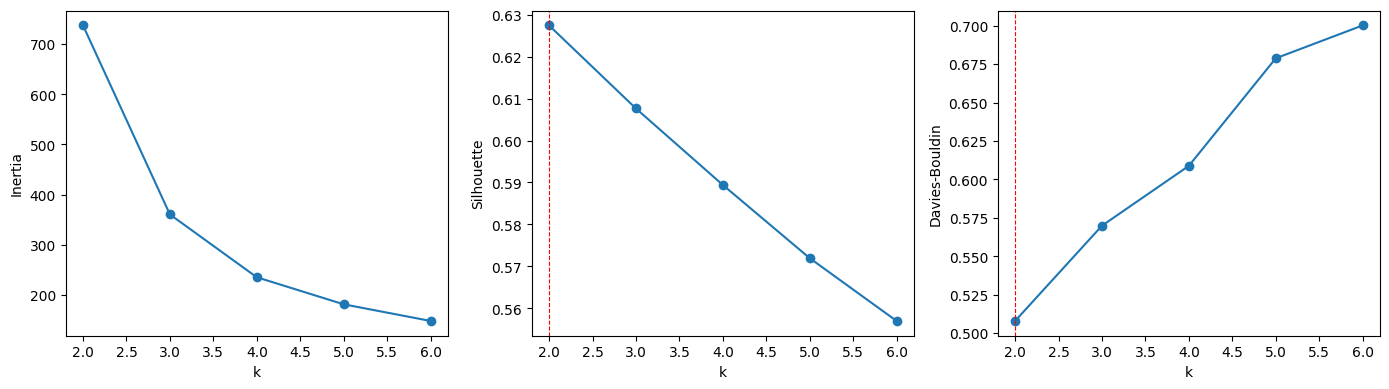

In [9]:
X_clust = score_matrix_norm

kmeans_results = {}
for k in KMEANS_K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_clust)
    kmeans_results[k] = {
        "model": km,
        "labels": labels,
        "silhouette": silhouette_score(X_clust, labels),
        "davies_bouldin": davies_bouldin_score(X_clust, labels),
        "inertia": km.inertia_,
    }

metrics_df = pd.DataFrame(
    [
        {
            "k": k,
            "inertia": v["inertia"],
            "silhouette": v["silhouette"],
            "davies_bouldin": v["davies_bouldin"],
        }
        for k, v in kmeans_results.items()
    ]
).set_index("k")

best_k = metrics_df["silhouette"].idxmax()
display(metrics_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(metrics_df.index, metrics_df["inertia"], marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(metrics_df.index, metrics_df["silhouette"], marker="o")
axes[1].axvline(best_k, color="red", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

axes[2].plot(metrics_df.index, metrics_df["davies_bouldin"], marker="o")
axes[2].axvline(best_k, color="red", linestyle="--", linewidth=0.8)
axes[2].set_xlabel("k")
axes[2].set_ylabel("Davies-Bouldin")

plt.tight_layout()
plt.show()

In [10]:
kmeans_final = kmeans_results[best_k]["model"]
raw_labels = kmeans_final.labels_

pnn_rates = {}
for c in range(best_k):
    mask = raw_labels == c
    pnn_rates[c] = preds_anom["pnn"][mask].mean() if mask.sum() > 0 else 0.0

sorted_by_pnn = sorted(pnn_rates, key=pnn_rates.get, reverse=True)
remap = {old: new for new, old in enumerate(sorted_by_pnn)}
cluster_labels = np.array([remap[c] for c in raw_labels])

cluster_names = {}
for new_c in range(best_k):
    old_c = sorted_by_pnn[new_c]
    rate = pnn_rates[old_c]
    if new_c == 0:
        cluster_names[new_c] = f"C0 - Spoofing-aligned (PNN rate={rate:.1%})"
    else:
        cluster_names[new_c] = f"C{new_c} - General anomaly {new_c}"

mapping_df = pd.DataFrame(
    {
        "cluster": [cluster_names[c] for c in range(best_k)],
        "size": [(cluster_labels == c).sum() for c in range(best_k)],
    }
)
display(mapping_df)

,cluster,size
0,C0 - Spoofing-aligned (PNN rate=0.8%),33049
1,C1 - General anomaly 1,37104


In [11]:
from sklearn.cluster import HDBSCAN as _HDBSCAN
from sklearn.metrics import adjusted_rand_score

min_cluster_size = max(5, n_anom_total // 20)
hdbscan_model = _HDBSCAN(min_cluster_size=min_cluster_size)
hdbscan_labels = hdbscan_model.fit_predict(X_clust)
n_hdb_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)

mask_valid = hdbscan_labels != -1
sil_hdb = np.nan
if mask_valid.sum() >= 2 and n_hdb_clusters >= 2:
    sil_hdb = silhouette_score(X_clust[mask_valid], hdbscan_labels[mask_valid])

agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agg_labels = agg.fit_predict(X_clust)
sil_agg = silhouette_score(X_clust, agg_labels)

ari = adjusted_rand_score(cluster_labels, agg_labels)
ari_hdb = np.nan
if n_hdb_clusters >= 2 and mask_valid.sum() > 0:
    ari_hdb = adjusted_rand_score(
        cluster_labels[mask_valid], hdbscan_labels[mask_valid]
    )

comparison_df = pd.DataFrame(
    {
        "method": ["KMeans", "HDBSCAN", "Agglomerative"],
        "n_clusters": [best_k, n_hdb_clusters, best_k],
        "silhouette": [kmeans_results[best_k]["silhouette"], sil_hdb, sil_agg],
        "ARI_vs_KMeans": [1.0, ari_hdb, ari],
    }
)
display(comparison_df.round(4))

,method,n_clusters,silhouette,ARI_vs_KMeans
0,KMeans,2,0.6274,1.0000
1,HDBSCAN,2,0.7057,0.4758
2,Agglomerative,2,0.6212,0.9296


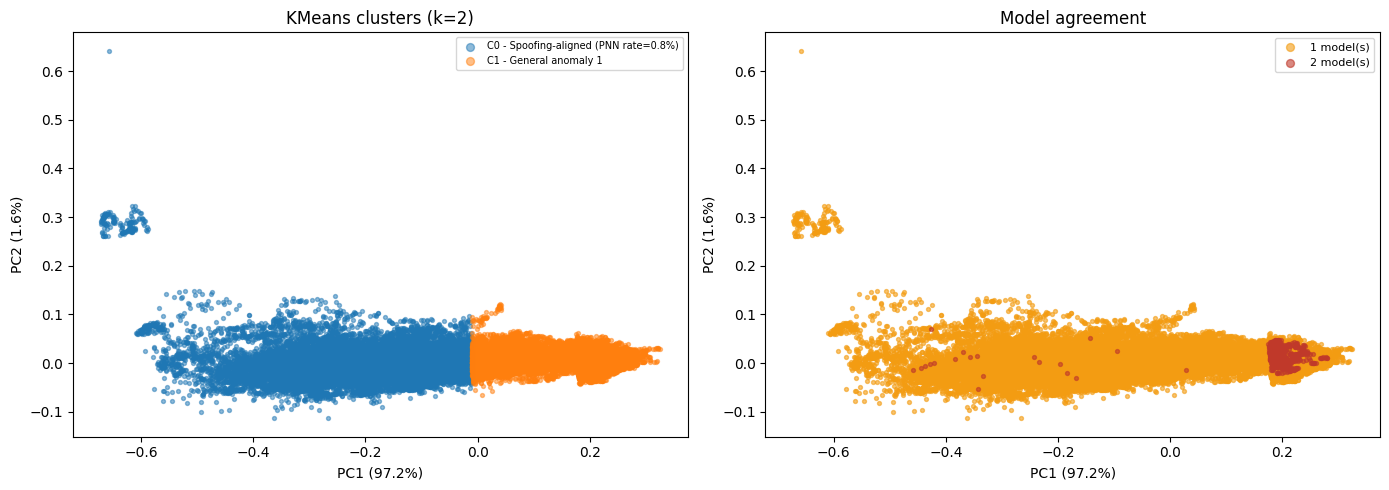

In [12]:
CLUSTER_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"][:best_k]

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clust)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for c in range(best_k):
    mask = cluster_labels == c
    axes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=8,
        alpha=0.5,
        color=CLUSTER_COLORS[c],
        label=cluster_names[c],
    )
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title(f"KMeans clusters (k={best_k})")
axes[0].legend(fontsize=7, markerscale=2)

agreement_colors = {1: "#f39c12", 2: "#c0392b", 3: "#008000"}
n_flagged_anom = n_models_flagged[anom_indices]
for n_models in sorted(set(n_flagged_anom)):
    if n_models == 0:
        continue
    mask = n_flagged_anom == n_models
    axes[1].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=8,
        alpha=0.6,
        color=agreement_colors.get(n_models, "#555555"),
        label=f"{n_models} model(s)",
    )
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("Model agreement")
axes[1].legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()

,N,Share (%),ocsvm_score_mean,ocsvm_det_rate,pnn_score_mean,pnn_det_rate,prae_score_mean,prae_det_rate
Cluster,,,,,,,,
C0 - Spoofing-aligned (PNN rate=0.8%),33049,47.11,0.5003,0.0000,0.9939,0.0079,0.1062,0.9927
C1 - General anomaly 1,37104,52.89,0.8288,0.6711,0.9996,0.0015,0.0841,0.3416


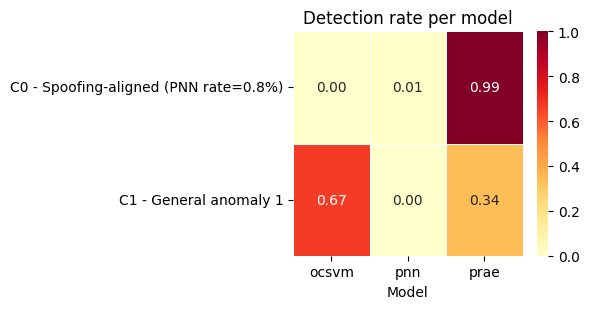

In [13]:
profile_rows = []
for c in range(best_k):
    mask = cluster_labels == c
    row = {
        "Cluster": cluster_names[c],
        "N": int(mask.sum()),
        "Share (%)": round(100 * mask.sum() / n_anom_total, 2),
    }
    for j, mt in enumerate(MODEL_TYPES):
        short = mt.replace("transformer_ocsvm", "ocsvm")
        row[f"{short}_score_mean"] = round(float(score_matrix_norm[mask, j].mean()), 4)
        row[f"{short}_det_rate"] = round(float(preds_anom[mt][mask].mean()), 4)
    profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows).set_index("Cluster")
display(profile_df)

det_cols = [c for c in profile_df.columns if c.endswith("_det_rate")]
det_df = profile_df[det_cols].rename(
    columns={c: c.replace("_det_rate", "") for c in det_cols}
)
fig, ax = plt.subplots(figsize=(6, 0.6 * best_k + 2))
sns.heatmap(
    det_df.astype(float),
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Detection rate per model")
ax.set_xlabel("Model")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [14]:
global_mean = feat_anom.mean()
global_std = feat_anom.std().replace(0, 1e-10)

summary_rows = []
for c in range(best_k):
    mask = cluster_labels == c
    n_c = int(mask.sum())

    if mask.any():
        period_counts = pd.Series(period_anom[mask]).value_counts()
        dominant_period = period_counts.idxmax() if not period_counts.empty else "-"
        c_mean = feat_anom.iloc[mask].mean()
        top_feat = ((c_mean - global_mean) / global_std).abs().idxmax()
    else:
        dominant_period = "-"
        top_feat = "-"

    pnn_rate = float(preds_anom["pnn"][mask].mean()) if mask.any() else 0.0
    ocsvm_rate = (
        float(preds_anom["transformer_ocsvm"][mask].mean()) if mask.any() else 0.0
    )
    prae_rate = float(preds_anom["prae"][mask].mean()) if mask.any() else 0.0

    if pnn_rate >= 0.5:
        hint = "spoofing-type"
    elif ocsvm_rate >= 0.5 and prae_rate >= 0.5:
        hint = "general (OC-SVM + PRAE)"
    elif ocsvm_rate >= 0.5:
        hint = "general (OC-SVM)"
    elif prae_rate >= 0.5:
        hint = "general (PRAE)"
    else:
        hint = "mixed"

    summary_rows.append(
        {
            "Cluster": cluster_names[c],
            "N": n_c,
            "Share (%)": round(100 * n_c / n_anom_total, 2),
            "OC-SVM det.": round(ocsvm_rate, 3),
            "PNN det.": round(pnn_rate, 3),
            "PRAE det.": round(prae_rate, 3),
            "Dominant period": dominant_period,
            "Top feature": top_feat,
            "Interpretation": hint,
        }
    )

summary_df = pd.DataFrame(summary_rows).set_index("Cluster")
display(summary_df)

,N,Share (%),OC-SVM det.,PNN det.,PRAE det.,Dominant period,Top feature,Interpretation
Cluster,,,,,,,,
C0 - Spoofing-aligned (PNN rate=0.8%),33049,47.11,0.000,0.008,0.993,afternoon,mid_price_volatility,general (PRAE)
C1 - General anomaly 1,37104,52.89,0.671,0.002,0.342,afternoon,mid_price_volatility,general (OC-SVM)
